In [64]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import sklearn
import imblearn
import shap
import xgboost

In [65]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv',usecols=['tenure','Contract','InternetService','OnlineSecurity','PaymentMethod','TechSupport','DeviceProtection','MonthlyCharges','OnlineBackup','TotalCharges','Churn'])

In [66]:
# from ydata_profiling import ProfileReport
# prof = ProfileReport(df)
# prof.to_file(output_file='output.html')

__UNDERSTAND DATASET__

In [67]:
df.sample(5)

,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn
5984,14,Fiber optic,No,No,No,No,Month-to-month,Electronic check,85.15,1139.2,Yes
5793,14,DSL,No,Yes,No,No,Month-to-month,Credit card (automatic),55.50,767.55,No
6233,3,No,No internet service,No internet service,No internet service,No internet service,Month-to-month,Mailed check,20.70,57.5,No
3401,56,No,No internet service,No internet service,No internet service,No internet service,Two year,Bank transfer (automatic),19.55,1080.55,No
519,12,No,No internet service,No internet service,No internet service,No internet service,Month-to-month,Credit card (automatic),20.05,265.45,No


In [68]:
df[df['TotalCharges'].str.strip()==""]

,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,0,DSL,Yes,No,Yes,Yes,Two year,Bank transfer (automatic),52.55,,No
753,0,No,No internet service,No internet service,No internet service,No internet service,Two year,Mailed check,20.25,,No
936,0,DSL,Yes,Yes,Yes,No,Two year,Mailed check,80.85,,No
1082,0,No,No internet service,No internet service,No internet service,No internet service,Two year,Mailed check,25.75,,No
1340,0,DSL,Yes,Yes,Yes,Yes,Two year,Credit card (automatic),56.05,,No
3331,0,No,No internet service,No internet service,No internet service,No internet service,Two year,Mailed check,19.85,,No
3826,0,No,No internet service,No internet service,No internet service,No internet service,Two year,Mailed check,25.35,,No
4380,0,No,No internet service,No internet service,No internet service,No internet service,Two year,Mailed check,20.00,,No
5218,0,No,No internet service,No internet service,No internet service,No internet service,One year,Mailed check,19.70,,No
6670,0,DSL,No,Yes,Yes,Yes,Two year,Mailed check,73.35,,No


In [69]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')

In [70]:
mean = df['TotalCharges'].mean()
mean

np.float64(2283.3004408418656)

In [71]:
df['TotalCharges'] = df['TotalCharges'].fillna(mean)
df['TotalCharges']

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

_Missing percentag_

In [72]:
df.isnull().mean()*100

tenure              0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
Contract            0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64

_Drop missing values_

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   tenure            7043 non-null   int64  
 1   InternetService   7043 non-null   object 
 2   OnlineSecurity    7043 non-null   object 
 3   OnlineBackup      7043 non-null   object 
 4   DeviceProtection  7043 non-null   object 
 5   TechSupport       7043 non-null   object 
 6   Contract          7043 non-null   object 
 7   PaymentMethod     7043 non-null   object 
 8   MonthlyCharges    7043 non-null   float64
 9   TotalCharges      7043 non-null   float64
 10  Churn             7043 non-null   object 
dtypes: float64(2), int64(1), object(8)
memory usage: 605.4+ KB


In [74]:
df.isnull().sum()

tenure              0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
Contract            0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [75]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2265.000258
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,402.225000
50%,29.000000,70.350000,1400.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [76]:
df.duplicated().sum()

np.int64(100)

__EDA__

__Univariant Analysis__

_tenure  Coloumn_

<Axes: ylabel='Frequency'>

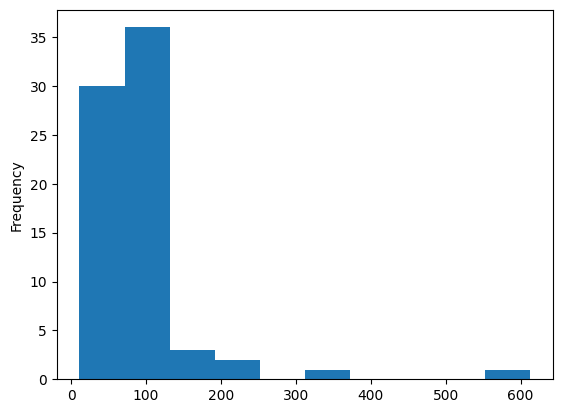

In [77]:
df['tenure'].value_counts().plot(kind='hist')

<Axes: ylabel='tenure'>

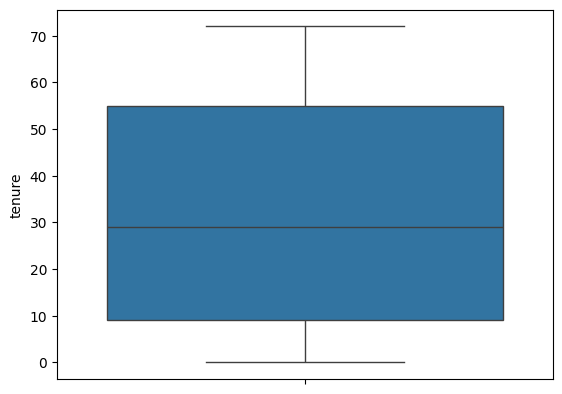

In [78]:
sns.boxplot(df['tenure'])

_InternetService Coloumn_

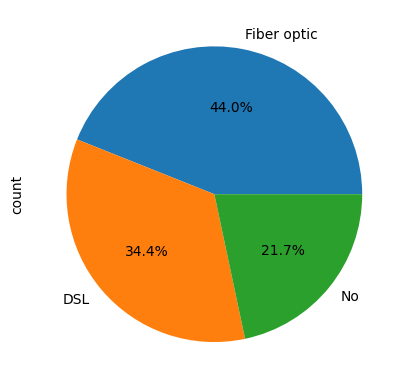

In [79]:
df['InternetService'].value_counts().plot(kind='pie', autopct='%0.1f%%')
plt.show()

_OnlineSecurity Coloumn_

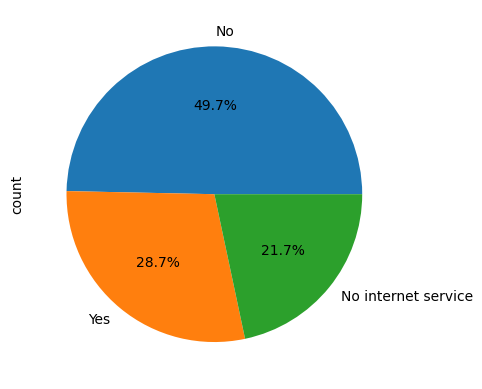

In [80]:
df['OnlineSecurity'].value_counts().plot(kind='pie', autopct='%0.1f%%')
plt.show()

_OnlineBackup Coloumn_

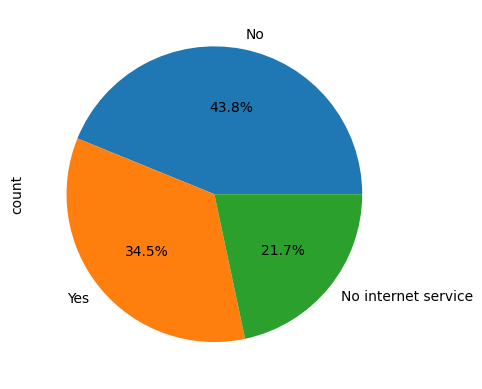

In [81]:
df['OnlineBackup'].value_counts().plot(kind='pie', autopct='%0.1f%%')
plt.show()

_DeviceProtection Coloumn_

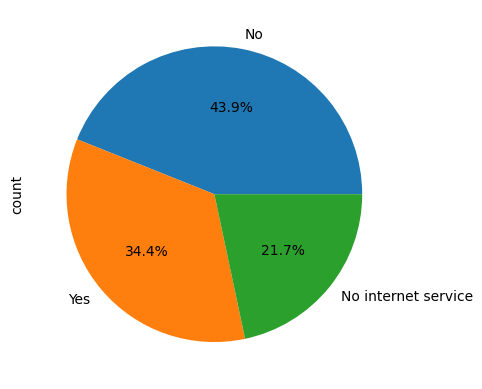

In [82]:
df['DeviceProtection'].value_counts().plot(kind='pie', autopct='%0.1f%%')
plt.show()

_TechSupport Coloumn_

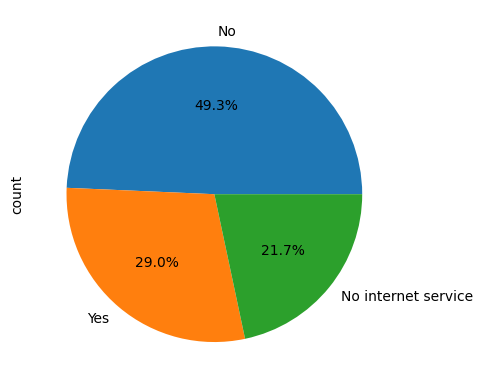

In [83]:
df['TechSupport'].value_counts().plot(kind='pie', autopct='%0.1f%%')
plt.show()

_Contract_

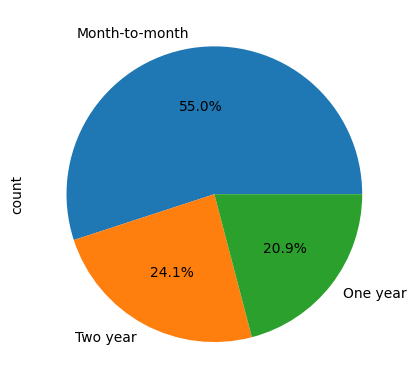

In [84]:
df['Contract'].value_counts().plot(kind='pie', autopct='%0.1f%%')
plt.show()

_PaymentMethod Coloumn_

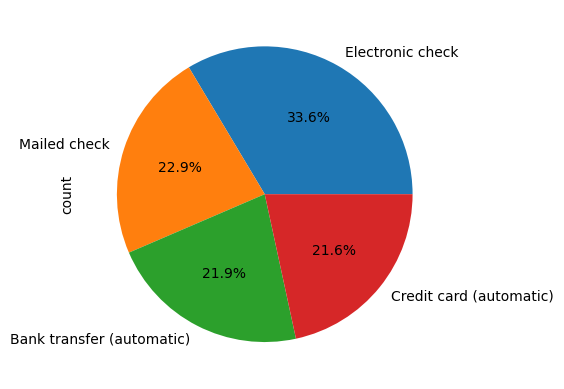

In [85]:
df['PaymentMethod'].value_counts().plot(kind='pie', autopct='%0.1f%%')
plt.show()

_Churn Coloumn_

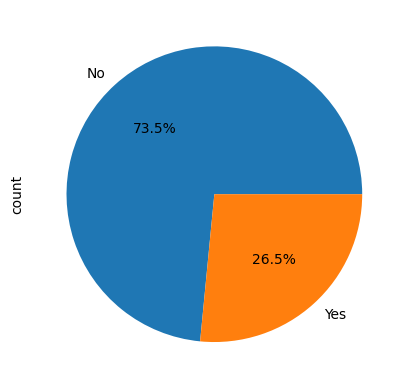

In [86]:
df['Churn'].value_counts().plot(kind='pie', autopct='%0.1f%%')
plt.show()

_MonthlyCharges Coloumn_

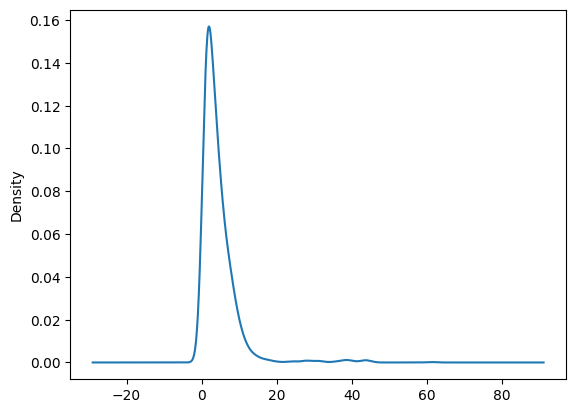

In [87]:
df['MonthlyCharges'].value_counts().plot(kind='kde')
plt.show()

<Axes: ylabel='MonthlyCharges'>

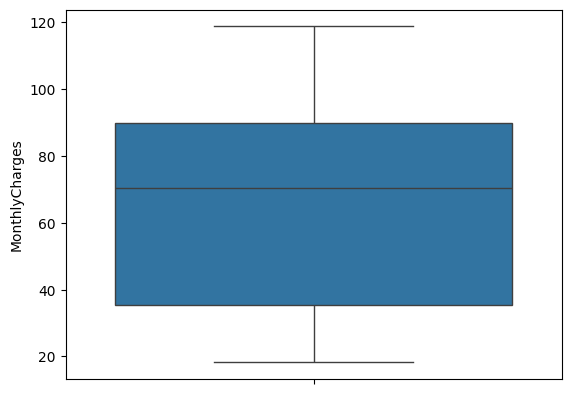

In [88]:
sns.boxplot(df['MonthlyCharges'])

_TotalCharges Coloumn_

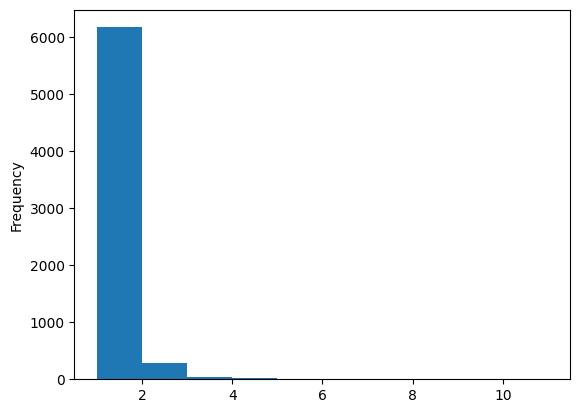

In [89]:
df['TotalCharges'].value_counts().plot(kind='hist')
plt.show()

__Checking Outliers__

<Axes: ylabel='TotalCharges'>

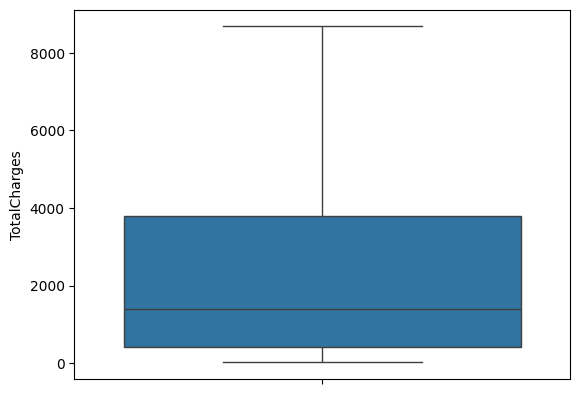

In [90]:
sns.boxplot(df['TotalCharges'])

In [91]:
percentile25 = df['TotalCharges'].quantile(0.25)
percentile75 = df['TotalCharges'].quantile(0.75)

In [92]:
iqr = percentile75 - percentile25
iqr

np.float64(3384.375)

In [93]:
upper_limit = percentile75 + 1.5*iqr
lower_limit = percentile25 - 1.5*iqr

In [94]:
print("Upper_Limit: ",upper_limit)
print("Lower_Limit: ",lower_limit)

Upper_Limit:  8863.1625
Lower_Limit:  -4674.3375


In [95]:
df[df['TotalCharges']>upper_limit]

,tenure,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn


__Bivariant Analysis__

__Categorical - Categorical coloumn analysis__

_Internet Service VS Churn_

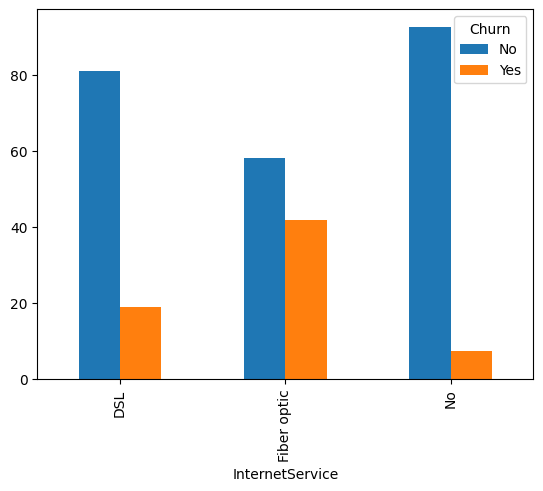

In [96]:
a = pd.crosstab(df['InternetService'],df['Churn'],normalize='index')*100
a.plot(kind='bar')
plt.show()

_Online Security VS Churn_

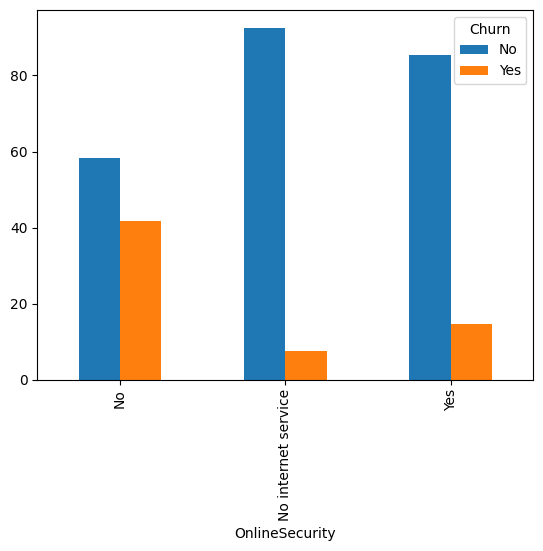

In [97]:
a = pd.crosstab(df['OnlineSecurity'],df['Churn'],normalize='index')*100
a.plot(kind='bar')
plt.show()

_Device protection VS Churn_

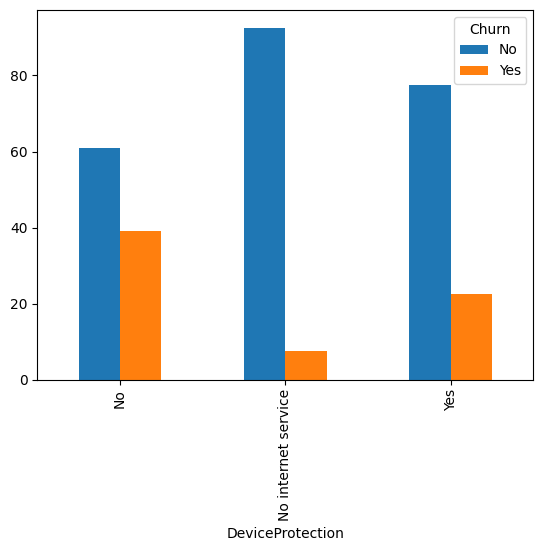

In [98]:
a = pd.crosstab(df['DeviceProtection'],df['Churn'],normalize='index')*100
a.plot(kind='bar')
plt.show()

_Tech Support VS Churn_

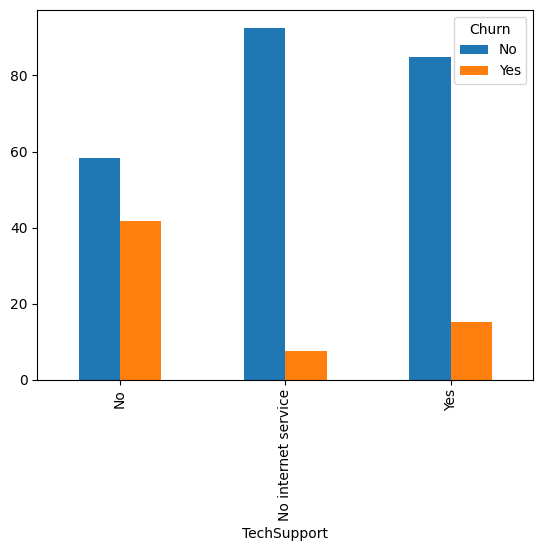

In [99]:
a = pd.crosstab(df['TechSupport'],df['Churn'],normalize='index')*100
a.plot(kind='bar')
plt.show()

_Contract  VS Churn_

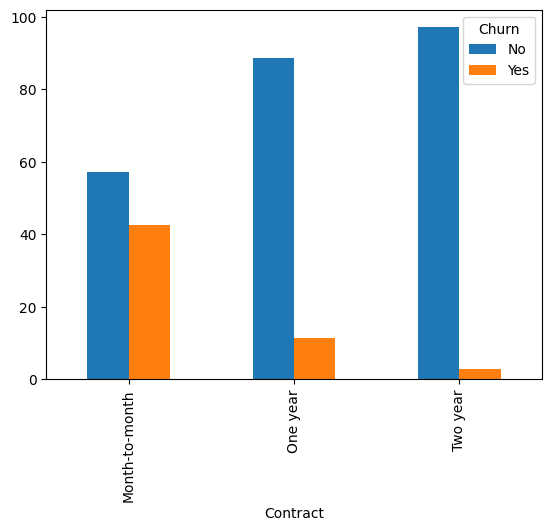

In [100]:
a = pd.crosstab(df['Contract'],df['Churn'],normalize='index')*100
a.plot(kind='bar')
plt.show()

_Payement Method VS Churn_

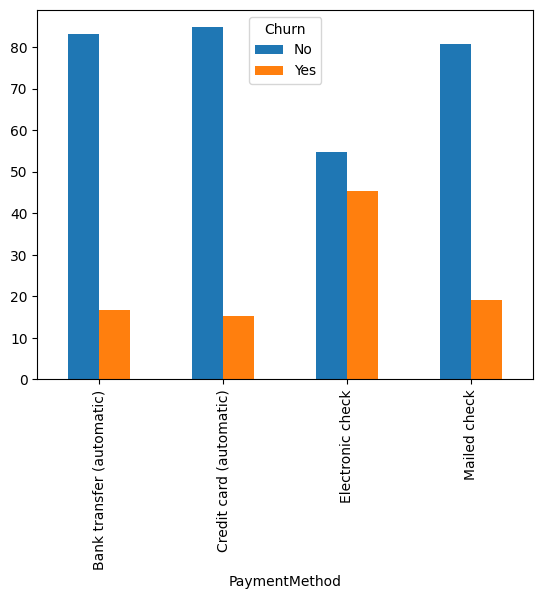

In [101]:
a = pd.crosstab(df['PaymentMethod'],df['Churn'],normalize='index')*100
a.plot(kind='bar')
plt.show()

__Categorical and Numerical Coloumns__

_Monthly Charges VS Churn_

C:\Users\hp\AppData\Local\Temp\ipykernel_13916\454255929.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Churn', y='MonthlyCharges', palette='summer')


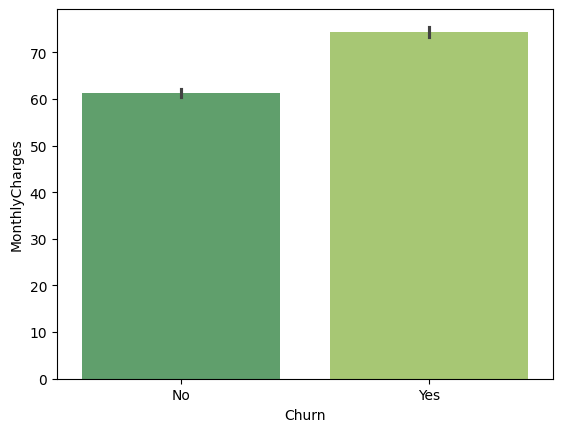

In [102]:
sns.barplot(data=df, x='Churn', y='MonthlyCharges', palette='summer')
plt.show()

_Tenure VS Churn_

C:\Users\hp\AppData\Local\Temp\ipykernel_13916\3630048016.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Churn', y='tenure', palette='summer')


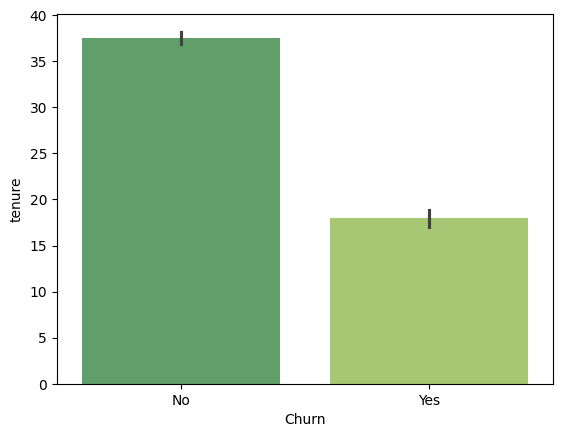

In [103]:
sns.barplot(data=df, x='Churn', y='tenure', palette='summer')
plt.show()

In [104]:
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler,StandardScaler,PowerTransformer
from sklearn.pipeline import  Pipeline,make_pipeline
from sklearn.feature_selection import SelectKBest,chi2
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn import set_config
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,ConfusionMatrixDisplay

__TRAIN TEST SPLIT__

In [105]:
X = df.drop(columns=['Churn'])
y = df['Churn']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [106]:
X_train.shape

(5634, 10)

__Logistic Regression__

In [107]:
numerical_features = ['tenure','MonthlyCharges','TotalCharges']
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),('power',PowerTransformer(method='yeo-johnson')),
    ('scaler',StandardScaler())
])

categorical_features = ['InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','Contract','PaymentMethod']
categorical_transformer = Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('ohe',OneHotEncoder(handle_unknown='ignore'))
])

In [108]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num',numerical_transformer,numerical_features),
        ('cat',categorical_transformer,categorical_features)
    ]
)

In [109]:
clf = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('classifier',LogisticRegression(class_weight='balanced',max_iter=1000))
])

In [110]:
set_config(display='diagram')
clf

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [111]:
param_grid = {
    'preprocessor__num__imputer__strategy':['mean','median'],
    'preprocessor__cat__imputer__strategy':['most_frequent','constant'],
    'classifier__C':[0.1,1.0,10,100]
}
grid_search = GridSearchCV(clf,param_grid,cv=10,scoring='accuracy',n_jobs=-1)

In [112]:
grid_search.fit(X_train,y_train)

print(f"Best params: ")
print(grid_search.best_params_)

Best params: 
{'classifier__C': 1.0, 'preprocessor__cat__imputer__strategy': 'most_frequent', 'preprocessor__num__imputer__strategy': 'mean'}


In [113]:
y_pre = grid_search.predict(X_test)

print("Accuracy LR: ",accuracy_score(y_test,y_pre))
print("Precission: ",precision_score(y_test,y_pre,pos_label='Yes'))
print("Recall: ",recall_score(y_test,y_pre,pos_label='Yes'))
print("F1: ",f1_score(y_test,y_pre,pos_label='Yes'))

Accuracy LR:  0.7501774308019872
Precission:  0.4962686567164179
Recall:  0.764367816091954
F1:  0.6018099547511312


In [114]:
print(y_train.value_counts())
print(y_test.value_counts())
print(pd.Series(y_pre).value_counts())

Churn
No     4113
Yes    1521
Name: count, dtype: int64
Churn
No     1061
Yes     348
Name: count, dtype: int64
No     873
Yes    536
Name: count, dtype: int64


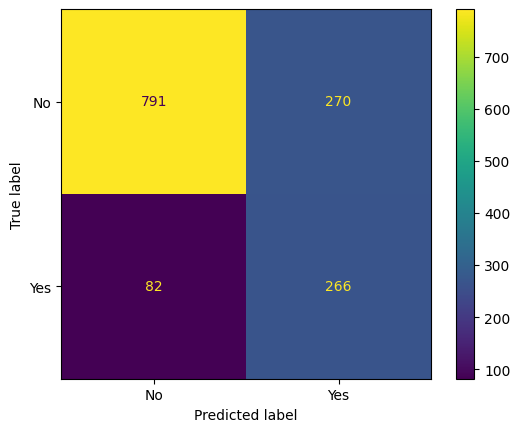

In [115]:
cm  =   confusion_matrix(y_test,y_pre,labels=["No","Yes"])
ConfusionMatrixDisplay(cm,display_labels=["No","Yes"]).plot()

__Cross Validation__

In [116]:
lr = LogisticRegression()
np.mean(cross_val_score(clf,X,y,scoring='accuracy'))

np.float64(0.7508158792502742)

__Exporting Pipeline__

In [117]:
import pickle
clf.fit(X_train,y_train)
pickle.dump(clf,open('churn.pkl','wb'))

__Load file__

In [118]:
pipe = pickle.load(open('churn.pkl','rb'))

__Assume User Input__

In [119]:
test_input = np.array([9,'DSL','No','No','No','No','Month-to-month','Bank transfer (automatic)',102.95,6886.25],dtype=object).reshape(1,10)
test = pd.DataFrame(test_input,columns=X_train.columns)

In [120]:
pipe.predict_proba(test)

array([[0.6426061, 0.3573939]])

In [121]:
pipe.predict(test)

array(['No'], dtype=object)